In [5]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.tensorboard import SummaryWriter
from torchvision.utils import make_grid
from sklearn.manifold import TSNE
import torch.nn.functional as F
from tqdm import tqdm

In [6]:
!pip install datasets

from datasets import load_dataset

ds = load_dataset("Falah/Alzheimer_MRI")

# Convert to Pandas if you want
hf_train_df = ds["train"].to_pandas()
hf_test_df = ds["test"].to_pandas()

print("✅ HF Train:", hf_train_df.shape)
print("✅ HF Test:", hf_test_df.shape)
print(hf_test_df.head())

✅ HF Train: (5120, 2)
✅ HF Test: (1280, 2)
                                               image  label
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      2
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0


In [7]:
from PIL import Image
import io

# Decode the first image from hf_test_df
image_bytes = hf_test_df.iloc[0]["image"]['bytes']
image = Image.open(io.BytesIO(image_bytes))

# Display the first image
image.show()

In [8]:
import numpy as np

# Function to convert byte data to an image array
def byte_to_image(image_bytes):
    image = Image.open(io.BytesIO(image_bytes))
    return np.array(image)

# Convert all images into NumPy arrays
hf_train_images = np.array([byte_to_image(img['bytes']) for img in hf_train_df['image']])
hf_test_images = np.array([byte_to_image(img['bytes']) for img in hf_test_df['image']])

print("✅ HF Train Images:", hf_train_images.shape)
print("✅ HF Test Images:", hf_test_images.shape)


✅ HF Train Images: (5120, 128, 128)
✅ HF Test Images: (1280, 128, 128)


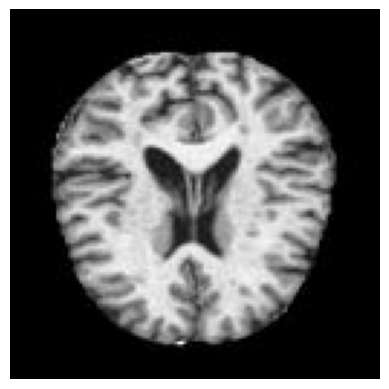

In [9]:
import matplotlib.pyplot as plt

def show_image_from_array(img, label=None):
    """
    Display a single image from a NumPy array.
    img: 2D (H,W) or 3D (H,W,C) NumPy array
    label: Optional label or title
    """
    # If the image is grayscale (H,W), use cmap="gray"
    # If it has 3 channels (H,W,3), you can omit cmap.

    # Check if it's grayscale vs. color
    if img.ndim == 2:
        # Grayscale
        plt.imshow(img, cmap="gray")
    else:
        # Color image
        plt.imshow(img)

    if label is not None:
        plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()



show_image_from_array(hf_train_images[0])



### We combine both datasets, extract and convert the images to 128x128, combine the labels (all alzheimers go together, the non-alzheimers go with normal). We store the data in a npz. The labels are still strings here, we convert them to numerical labels later

In [10]:
import os
import io
import numpy as np
from PIL import Image
from datasets import load_dataset, Dataset
import pandas as pd
from tqdm import tqdm

# Set the target image size (width, height)
TARGET_SIZE = (128, 128)

# --- Helper Functions ---

def preprocess_image_from_bytes(image_bytes, target_size=TARGET_SIZE):
    """
    Load image from byte data, convert to grayscale and resize.
    Uses Image.Resampling.LANCZOS for high-quality downsampling.
    """
    try:
        image = Image.open(io.BytesIO(image_bytes))
        image = image.convert("L")  # Convert to grayscale
        image = image.resize(target_size, Image.Resampling.LANCZOS)
        # Optionally add a channel dimension: np.expand_dims(np.array(image), axis=-1)
        return np.array(image)  # shape: (128, 128)
    except Exception as e:
        print(f"Error processing image from bytes: {e}")
        return None

def preprocess_image_from_path(image_path, target_size=TARGET_SIZE):
    """
    Load image from file path, convert to grayscale and resize.
    """
    try:
        image = Image.open(image_path)
        image = image.convert("L")  # Convert to grayscale
        image = image.resize(target_size, Image.Resampling.LANCZOS)
        # Optionally add a channel dimension: np.expand_dims(np.array(image), axis=-1)
        return np.array(image)  # shape: (128, 128)
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

def load_images_from_folder(folder_path, label, target_size=TARGET_SIZE):
    """
    Load all images (jpg, jpeg, png) from a folder and assign the given label.
    """
    images = []
    labels = []
    for file in os.listdir(folder_path):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_path = os.path.join(folder_path, file)
            img = preprocess_image_from_path(image_path, target_size)
            if img is not None:
                images.append(img)
                labels.append(label)
    return images, labels

# --- 1. Load and Process the Hugging Face Dataset ---

print("Loading Hugging Face Alzheimer_MRI dataset...")
hf_ds = load_dataset("Falah/Alzheimer_MRI")

# Convert train and test splits to Pandas DataFrames for easy processing.
hf_train_df = hf_ds["train"].to_pandas()
hf_test_df = hf_ds["test"].to_pandas()

print("HF Train shape:", hf_train_df.shape)
print("HF Test shape:", hf_test_df.shape)

# Process images from the HF dataset (which come as byte data).
hf_train_images = []
for img_info in hf_train_df['image']:
    img = preprocess_image_from_bytes(img_info['bytes'])
    if img is not None:
        hf_train_images.append(img)

hf_test_images = []
for img_info in hf_test_df['image']:
    img = preprocess_image_from_bytes(img_info['bytes'])
    if img is not None:
        hf_test_images.append(img)

# Re-labeling: if the original label is 2, we mark it as "normal"; otherwise, "alzheimers"
hf_train_labels = ["normal" if label == 2 else "alzheimers" for label in hf_train_df['label']]
hf_test_labels  = ["normal" if label == 2 else "alzheimers" for label in hf_test_df['label']]

# Combine train and test parts
hf_images = hf_train_images + hf_test_images
hf_labels = hf_train_labels + hf_test_labels

print(f"Processed {len(hf_images)} images from Hugging Face dataset.")

# --- 2. Load and Process Local Folders ---

# Replace these paths with your actual local directory paths.
alzheimer_folder  = "./alzheimers_dataset"   # e.g., images with filenames like "mild_648.jpg"
normal_folder     = "./normal"              # contains normal images (jpg/png, various sizes)
parkinsons_folder = "./parkinsons_dataset"   # contains Parkinson's images

print("Loading local Alzheimer images...")
local_alzheimer_images, local_alzheimer_labels = load_images_from_folder(alzheimer_folder, "alzheimers")

print("Loading local Normal images...")
local_normal_images, local_normal_labels = load_images_from_folder(normal_folder, "normal")

print("Loading local Parkinson's images...")
local_parkinsons_images, local_parkinsons_labels = load_images_from_folder(parkinsons_folder, "parkinsons")

# Combine local images and labels
local_images = local_alzheimer_images + local_normal_images + local_parkinsons_images
local_labels = local_alzheimer_labels + local_normal_labels + local_parkinsons_labels

print(f"Processed {len(local_images)} local images.")

# --- 3. Combine All Data ---

all_images = hf_images + local_images
all_labels  = hf_labels  + local_labels
print(f"Total combined images before filtering: {len(all_images)}")

# Filter out any None images (in case any failed to process)
filtered = [(img, label) for img, label in zip(all_images, all_labels) if img is not None]
if filtered:
    all_images, all_labels = zip(*filtered)
    all_images = list(all_images)
    all_labels = list(all_labels)
else:
    all_images, all_labels = [], []

print(f"Total combined images after filtering: {len(all_images)}")

# --- 4. Save the Combined Dataset ---

# Option 1: Save as a compressed NPZ file.
all_images_np = np.array(all_images)
all_labels_np = np.array(all_labels)
npz_filename = "combined_dataset.npz"
np.savez(npz_filename, images=all_images_np, labels=all_labels_np)
print(f"Combined dataset saved to {npz_filename}")

# Option 2: Save using Hugging Face's Dataset library.
# Convert images to lists so that they are JSON serializable.
data_dict = {
    "image": [img.tolist() for img in tqdm(all_images, desc="Converting images to lists")],
    "label": list(all_labels)
}
combined_dataset = Dataset.from_dict(data_dict)
combined_dataset.save_to_disk("combined_dataset2")
print("Combined dataset saved using Hugging Face's Dataset to the directory 'combined_dataset'.")


Loading Hugging Face Alzheimer_MRI dataset...
HF Train shape: (5120, 2)
HF Test shape: (1280, 2)
Processed 6400 images from Hugging Face dataset.
Loading local Alzheimer images...
Loading local Normal images...
Loading local Parkinson's images...
Processed 7590 local images.
Total combined images before filtering: 13990
Total combined images after filtering: 13990
Combined dataset saved to combined_dataset.npz


Saving the dataset (4/4 shards): 100%|██████████| 13990/13990 [00:03<00:00, 4154.26 examples/s]

Combined dataset saved using Hugging Face's Dataset to the directory 'combined_dataset'.


## Show some examples of the downscaling to show that the images are mostly the same

Examples from the Alzheimer folder:
Examples from the Normal folder:


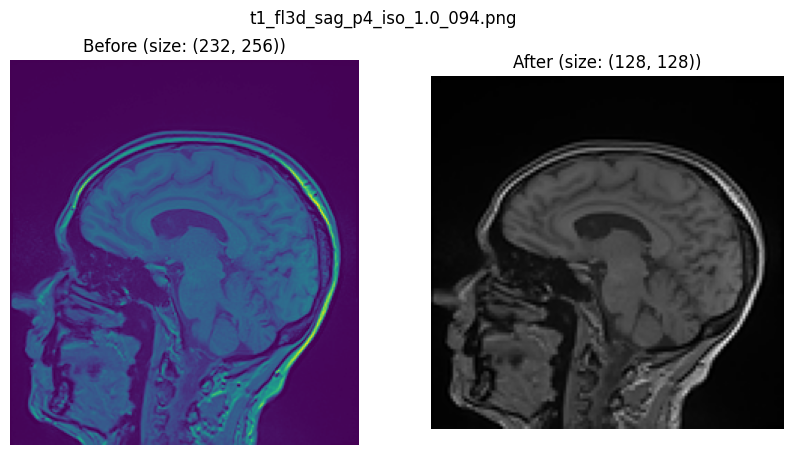

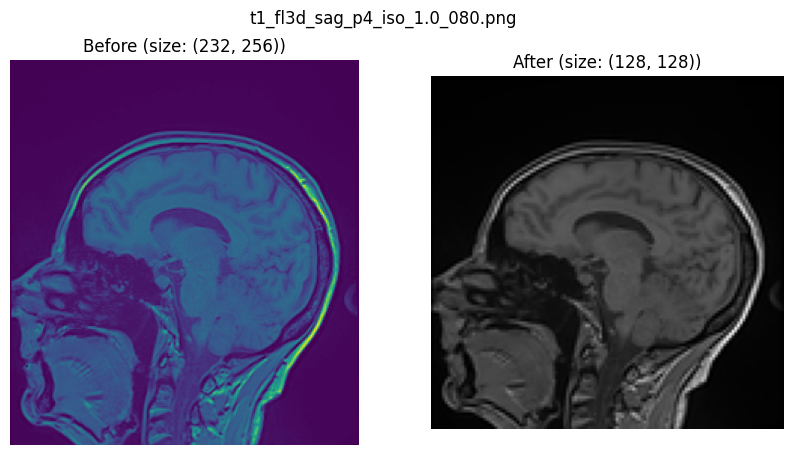

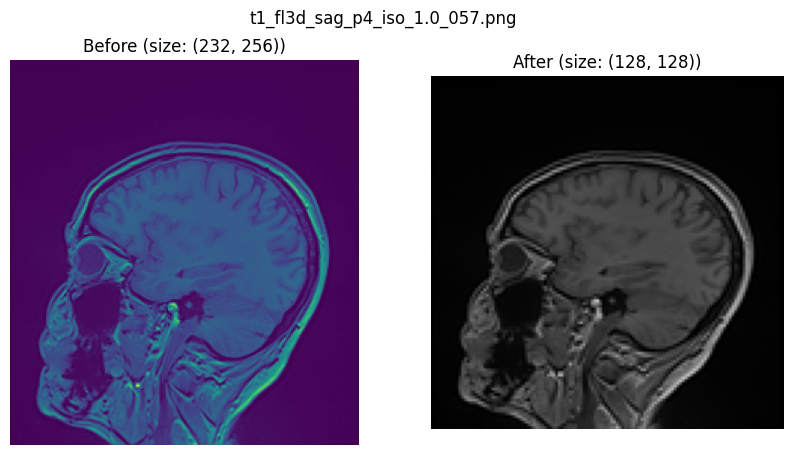

Examples from the Parkinson's folder:


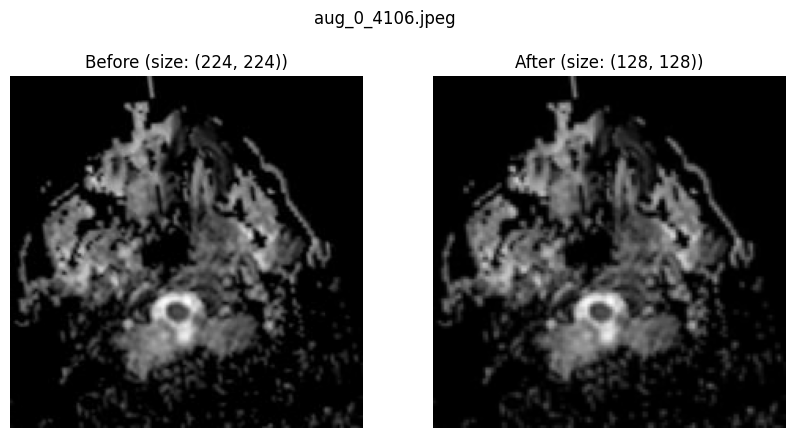

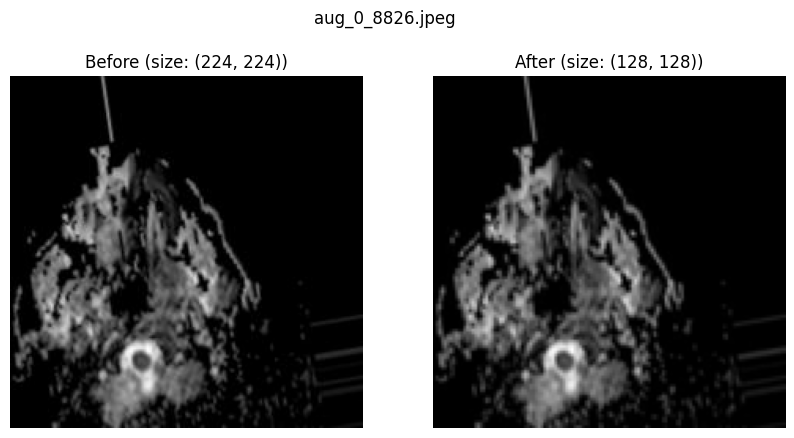

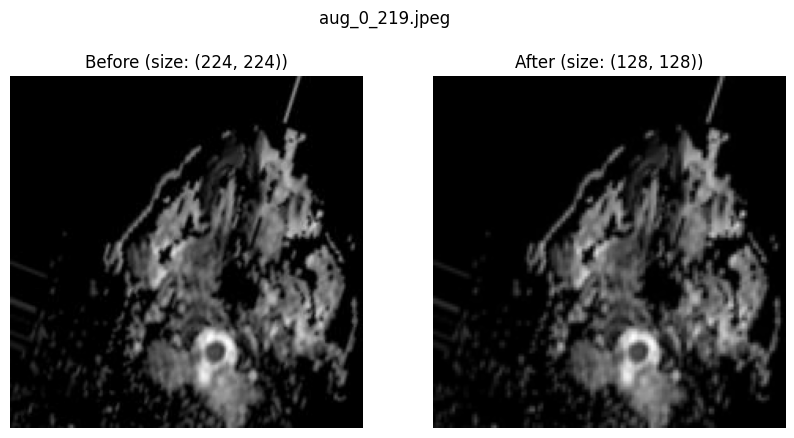

In [11]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Set target size
TARGET_SIZE = (128, 128)

def show_before_after(folder_path, target_size=TARGET_SIZE, max_examples=3):
    """
    For images in folder_path whose size does not match target_size,
    display the original image and its resized version side by side.
    """
    examples_shown = 0
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            file_path = os.path.join(folder_path, filename)
            try:
                # Open the original image
                original = Image.open(file_path)
            except Exception as e:
                print(f"Error opening image {file_path}: {e}")
                continue

            # If the image size is not equal to the target size, show it
            if original.size != target_size:
                # Resize image (first converting to RGB to ensure consistency)
                resized = original.convert("RGB").resize(target_size, Image.Resampling.LANCZOS)
                
                # Plot before (original) and after (resized) side by side
                fig, axes = plt.subplots(1, 2, figsize=(10, 5))
                axes[0].imshow(original)
                axes[0].set_title(f"Before (size: {original.size})")
                axes[0].axis("off")
                
                axes[1].imshow(resized)
                axes[1].set_title(f"After (size: {target_size})")
                axes[1].axis("off")
                
                plt.suptitle(filename)
                plt.show()
                
                examples_shown += 1
                if examples_shown >= max_examples:
                    break

# Define your folder paths
alzheimer_folder  = "./alzheimers_dataset"   # e.g., images with filenames like "mild_648.jpg"
normal_folder     = "./normal"              # contains normal images (jpg/png, various sizes)
parkinsons_folder = "./parkinsons_dataset"   # contains Parkinson's images

# Show examples for each folder:
print("Examples from the Alzheimer folder:")
show_before_after(alzheimer_folder, TARGET_SIZE, max_examples=3)

print("Examples from the Normal folder:")
show_before_after(normal_folder, TARGET_SIZE, max_examples=3)

print("Examples from the Parkinson's folder:")
show_before_after(parkinsons_folder, TARGET_SIZE, max_examples=3)


### Show what percentage of the images we had to resize per folder/dataset

Processing ./alzheimers_dataset: 100%|██████████| 2500/2500 [00:00<00:00, 9256.86it/s]



Folder: ./alzheimers_dataset
Total images: 2500
Images not of size (128, 128): 0 (0.00%)
No examples to show for ./alzheimers_dataset.


Processing ./normal: 100%|██████████| 2699/2699 [00:00<00:00, 3000.42it/s]



Folder: ./normal
Total images: 2699
Images not of size (128, 128): 610 (22.60%)


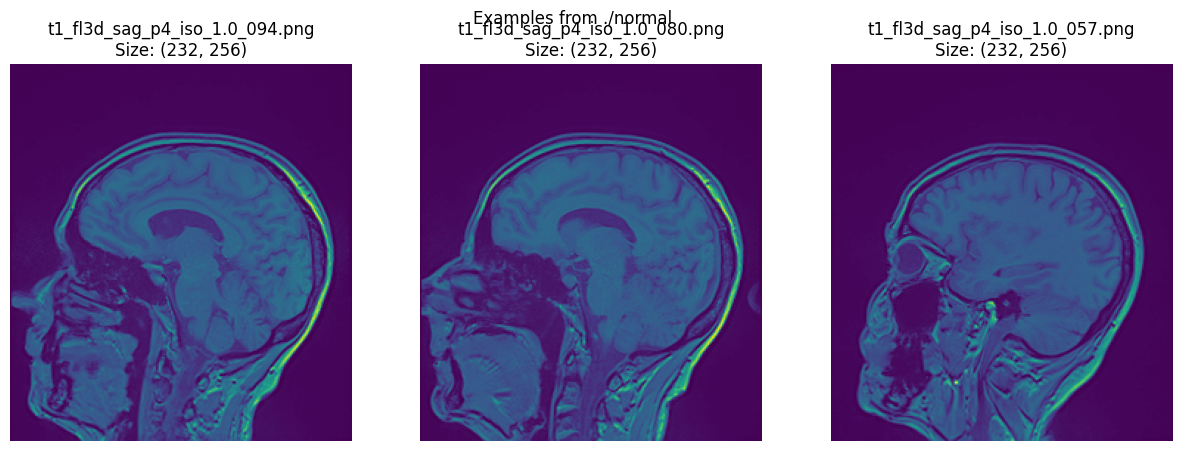

Processing ./parkinsons_dataset: 100%|██████████| 2391/2391 [00:00<00:00, 3545.16it/s]



Folder: ./parkinsons_dataset
Total images: 2391
Images not of size (128, 128): 2281 (95.40%)


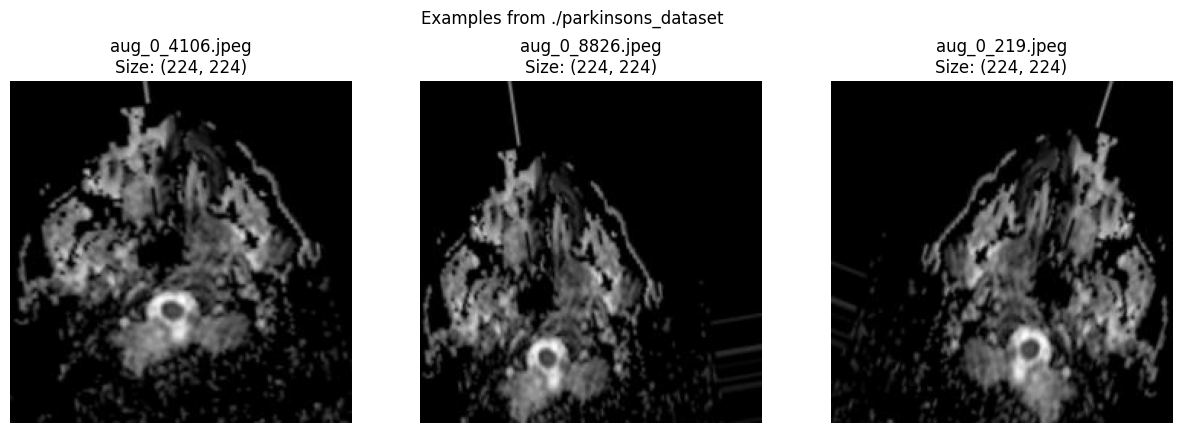

In [12]:
import os
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# Define target size and folder paths
TARGET_SIZE = (128, 128)
alzheimer_folder  = "./alzheimers_dataset"   # e.g., images with filenames like "mild_648.jpg"
normal_folder     = "./normal"              # contains normal images (jpg/png, various sizes)
parkinsons_folder = "./parkinsons_dataset"   # contains Parkinson's images

def analyze_folder(folder_path, target_size=TARGET_SIZE, max_examples=3):
    """
    Analyzes the images in a folder:
      - Computes the percentage of images that are NOT of the target size.
      - Returns a list of examples (filename, image, original size) for images not at target_size.
    """
    total_images = 0
    non_target_count = 0
    examples = []  # to store (filename, image, original size)
    
    # Process files with tqdm for a progress bar
    for filename in tqdm(os.listdir(folder_path), desc=f"Processing {folder_path}"):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            total_images += 1
            file_path = os.path.join(folder_path, filename)
            try:
                img = Image.open(file_path)
            except Exception as e:
                print(f"Error opening {file_path}: {e}")
                continue
            orig_size = img.size
            if orig_size != target_size:
                non_target_count += 1
                # Save a few examples if we haven't reached max_examples
                if len(examples) < max_examples:
                    examples.append((filename, img.copy(), orig_size))
    # Calculate percentage
    percent_non_target = (non_target_count / total_images * 100) if total_images > 0 else 0
    print(f"\nFolder: {folder_path}")
    print(f"Total images: {total_images}")
    print(f"Images not of size {target_size}: {non_target_count} ({percent_non_target:.2f}%)")
    
    return examples

def show_examples(examples, folder_path):
    """
    Displays example images (original version) with their filename and original size.
    """
    if not examples:
        print(f"No examples to show for {folder_path}.")
        return

    num_examples = len(examples)
    plt.figure(figsize=(5 * num_examples, 5))
    for i, (filename, img, orig_size) in enumerate(examples):
        plt.subplot(1, num_examples, i+1)
        plt.imshow(img)
        plt.title(f"{filename}\nSize: {orig_size}")
        plt.axis("off")
    plt.suptitle(f"Examples from {folder_path}")
    plt.show()

# List of folders to analyze
folders = [alzheimer_folder, normal_folder, parkinsons_folder]

for folder in folders:
    examples = analyze_folder(folder)
    show_examples(examples, folder)


### Training Working

In [ ]:
# TRAINING WORKING

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter

import torch

# Use MPS if available on your M1
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS device")
else:
    device = torch.device("cpu")
    print("Using CPU")



# --- 1. Load the NPZ File and Prepare the Data ---
data = np.load("combined_dataset.npz", allow_pickle=True)
images = data["images"]   # shape: (N, 128, 128)
labels = data["labels"]

# Add channel dimension (from (N, 128, 128) to (N, 1, 128, 128))
if images.ndim == 3:
    images = np.expand_dims(images, axis=1)

# Normalize images to [0, 1]
images = images.astype("float32") / 255.0

# Encode string labels into integers
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
num_classes = len(np.unique(labels_encoded))
print("Number of classes:", num_classes)

# --- 2. Create a Custom PyTorch Dataset ---
class NPZDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

dataset = NPZDataset(images, labels_encoded)
print("Total samples:", len(dataset))

# --- 3. Split Dataset into Training and Validation Sets ---
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# --- 4. Define a Simple CNN Model in PyTorch ---
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1   = nn.Linear(128 * 16 * 16, 128)
        self.fc2   = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))  # (batch, 32, 128, 128)
        x = self.pool(x)           # (batch, 32, 64, 64)
        x = F.relu(self.conv2(x))  # (batch, 64, 64, 64)
        x = self.pool(x)           # (batch, 64, 32, 32)
        x = F.relu(self.conv3(x))  # (batch, 128, 32, 32)
        x = self.pool(x)           # (batch, 128, 16, 16)
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN(num_classes=num_classes)
print(model)

# --- 5. Training Setup with TensorBoard Logging ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 10

# Create a TensorBoard SummaryWriter to log metrics
writer = SummaryWriter(log_dir="runs/simple_cnn_experiment")

# --- 6. Training Loop with Granular Progress Indicators ---
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Training", leave=False)
    
    for batch_idx, (inputs, targets) in enumerate(train_bar):
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        train_bar.set_postfix(loss=f"{running_loss/(batch_idx+1):.4f}")
    
    avg_loss = running_loss / len(train_loader)
    
    # Log training loss for the epoch
    writer.add_scalar("Loss/Train", avg_loss, epoch)
    
    # Validation phase with progress bar
    model.eval()
    correct = 0
    total = 0
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} Validation", leave=False)
    with torch.no_grad():
        for inputs, targets in val_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            total += targets.size(0)
            correct += (preds == targets).sum().item()
            val_bar.set_postfix(acc=f"{correct/total:.4f}")
    
    val_accuracy = correct / total
    writer.add_scalar("Accuracy/Validation", val_accuracy, epoch)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

# Save the trained model
torch.save(model.state_dict(), "simple_cnn.pth")
print("Model saved as simple_cnn.pth")

# Close the TensorBoard writer
writer.close()


Number of classes: 3
Total samples: 13990
Training samples: 11192
Validation samples: 2798
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)


Epoch 1/10, Loss: 0.5771, Val Accuracy: 0.7866


KeyboardInterrupt: 

# Optimizing Training for M1

In [17]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter

# --- Set the Device for M1 ---
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS device")
else:
    device = torch.device("cpu")
    print("Using CPU")

# --- 1. Load the NPZ File and Prepare the Data ---
data = np.load("combined_dataset.npz", allow_pickle=True)
images = data["images"]   # expected shape: (N, 128, 128) for grayscale images
labels = data["labels"]

# Add channel dimension (from (N, 128, 128) to (N, 1, 128, 128))
if images.ndim == 3:
    images = np.expand_dims(images, axis=1)

# Normalize images to [0, 1]
images = images.astype("float32") / 255.0

# Encode string labels into integers
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
num_classes = len(np.unique(labels_encoded))
print("Number of classes:", num_classes)

# --- 2. Create a Custom PyTorch Dataset ---
class NPZDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

dataset = NPZDataset(images, labels_encoded)
print("Total samples:", len(dataset))

# --- 3. Split Dataset into Training and Validation Sets ---
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# --- 4. Define a Simple CNN Model in PyTorch ---
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1   = nn.Linear(128 * 16 * 16, 128)
        self.fc2   = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))  # (batch, 32, 128, 128)
        x = self.pool(x)           # (batch, 32, 64, 64)
        x = F.relu(self.conv2(x))  # (batch, 64, 64, 64)
        x = self.pool(x)           # (batch, 64, 32, 32)
        x = F.relu(self.conv3(x))  # (batch, 128, 32, 32)
        x = self.pool(x)           # (batch, 128, 16, 16)
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN(num_classes=num_classes)
print(model)

# --- Move Model to the Selected Device ---
model.to(device)

# --- 5. Training Setup with TensorBoard Logging ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 10

# Create a TensorBoard SummaryWriter to log metrics
writer = SummaryWriter(log_dir="runs/simple_cnn_experiment")

# --- 6. Training Loop with Granular Progress Indicators ---
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Training", leave=False)
    
    for batch_idx, (inputs, targets) in enumerate(train_bar):
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        train_bar.set_postfix(loss=f"{running_loss/(batch_idx+1):.4f}")
    
    avg_loss = running_loss / len(train_loader)
    writer.add_scalar("Loss/Train", avg_loss, epoch)
    
    # --- Validation Phase ---
    model.eval()
    correct = 0
    total = 0
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} Validation", leave=False)
    with torch.no_grad():
        for inputs, targets in val_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            total += targets.size(0)
            correct += (preds == targets).sum().item()
            val_bar.set_postfix(acc=f"{correct/total:.4f}")
    
    val_accuracy = correct / total
    writer.add_scalar("Accuracy/Validation", val_accuracy, epoch)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

# Save the trained model
torch.save(model.state_dict(), "simple_cnn.pth")
print("Model saved as simple_cnn.pth")

# Close the TensorBoard writer
writer.close()


Using MPS device
Number of classes: 3
Total samples: 13990
Training samples: 11192
Validation samples: 2798
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)


Epoch 1/10, Loss: 0.5652, Val Accuracy: 0.7480


Epoch 2/10, Loss: 0.4083, Val Accuracy: 0.8259


Epoch 3/10, Loss: 0.2922, Val Accuracy: 0.9135


Epoch 4/10, Loss: 0.1479, Val Accuracy: 0.9578


...

Epoch 6/10, Loss: 0.0301, Val Accuracy: 0.9886


Epoch 7/10, Loss: 0.0093, Val Accuracy: 0.9886


Epoch 8/10, Loss: 0.0098, Val Accuracy: 0.9961


Epoch 9/10, Loss: 0.0200, Val Accuracy: 0.9828


Epoch 10/10, Loss: 0.0106, Val Accuracy: 0.9993
Model saved as simple_cnn.pth


### This next version should record last layer embeddings so we can perform tsne on it or something

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter

# --- Set the Device for M1 ---
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS device")
else:
    device = torch.device("cpu")
    print("Using CPU")

# --- 1. Load the NPZ File and Prepare the Data ---
data = np.load("combined_dataset.npz", allow_pickle=True)
images = data["images"]   # expected shape: (N, 128, 128) for grayscale images
labels = data["labels"]

# Add channel dimension (from (N, 128, 128) to (N, 1, 128, 128))
if images.ndim == 3:
    images = np.expand_dims(images, axis=1)

# Normalize images to [0, 1]
images = images.astype("float32") / 255.0

# Encode string labels into integers
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
num_classes = len(np.unique(labels_encoded))
print("Number of classes:", num_classes)

# --- 2. Create a Custom PyTorch Dataset ---
class NPZDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

dataset = NPZDataset(images, labels_encoded)
print("Total samples:", len(dataset))

# --- 3. Split Dataset into Training and Validation Sets ---
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# --- 4. Define a Simple CNN Model in PyTorch with Optional Embedding Output ---
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1   = nn.Linear(128 * 16 * 16, 128)
        self.fc2   = nn.Linear(128, num_classes)
        
    def forward(self, x, return_embedding=False):
        x = F.relu(self.conv1(x))   # (batch, 32, 128, 128)
        x = self.pool(x)            # (batch, 32, 64, 64)
        x = F.relu(self.conv2(x))   # (batch, 64, 64, 64)
        x = self.pool(x)            # (batch, 64, 32, 32)
        x = F.relu(self.conv3(x))   # (batch, 128, 32, 32)
        x = self.pool(x)            # (batch, 128, 16, 16)
        x = x.view(x.size(0), -1)   # Flatten
        embedding = F.relu(self.fc1(x))  # Second-to-last layer activations
        out = self.fc2(embedding)
        if return_embedding:
            return out, embedding
        else:
            return out

model = SimpleCNN(num_classes=num_classes)
print(model)

# --- Move Model to the Selected Device ---
model.to(device)

# --- 5. Training Setup with TensorBoard Logging ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 10

# Create a TensorBoard SummaryWriter to log metrics
writer = SummaryWriter(log_dir="runs/simple_cnn_experiment")

# --- 6. Training Loop with Granular Progress Indicators and Embedding Logging ---
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Training", leave=False)
    
    for batch_idx, (inputs, targets) in enumerate(train_bar):
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)  # Forward pass (without embeddings)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        train_bar.set_postfix(loss=f"{running_loss/(batch_idx+1):.4f}")
    
    avg_loss = running_loss / len(train_loader)
    writer.add_scalar("Loss/Train", avg_loss, epoch)
    
    # --- Validation Phase ---
    model.eval()
    correct = 0
    total = 0
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} Validation", leave=False)
    with torch.no_grad():
        for inputs, targets in val_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            total += targets.size(0)
            correct += (preds == targets).sum().item()
            val_bar.set_postfix(acc=f"{correct/total:.4f}")
    
    val_accuracy = correct / total
    writer.add_scalar("Accuracy/Validation", val_accuracy, epoch)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    
    # --- Embedding Visualization ---
    # Collect fc1 embeddings and labels from the entire validation set.
    all_embeddings = []
    all_val_labels = []
    model.eval()
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            # Get both output and fc1 embeddings by setting return_embedding=True
            _, embeddings = model(inputs, return_embedding=True)
            all_embeddings.append(embeddings.cpu())
            all_val_labels.append(targets.cpu())
    all_embeddings = torch.cat(all_embeddings, dim=0)
    all_val_labels = torch.cat(all_val_labels, dim=0)
    
    # Create a metadata list with class names (e.g., "Class 0", "Class 1", etc.)
    metadata = [f"Class {int(label)}" for label in all_val_labels]
    
    # Log embeddings (TensorBoard will assign distinct colors for each unique metadata value)
    writer.add_embedding(all_embeddings, metadata=metadata, global_step=epoch, tag="FC1_Embeddings")

# Save the trained model
torch.save(model.state_dict(), "simple_cnn_embeddings.pth")
print("Model saved as simple_cnn_embeddings.pth")

# Close the TensorBoard writer
writer.close()


Using MPS device
Number of classes: 3
Total samples: 13990
Training samples: 11192
Validation samples: 2798
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)


Epoch 1/10, Loss: 0.5402, Val Accuracy: 0.7802


Epoch 2/10, Loss: 0.3919, Val Accuracy: 0.8545


Epoch 3/10, Loss: 0.2665, Val Accuracy: 0.8989


Epoch 4/10, Loss: 0.1325, Val Accuracy: 0.9664


...

Epoch 6/10, Loss: 0.0257, Val Accuracy: 0.9793


Epoch 7/10, Loss: 0.0271, Val Accuracy: 0.9904


Epoch 8/10, Loss: 0.0205, Val Accuracy: 0.9921


Epoch 9/10, Loss: 0.0075, Val Accuracy: 0.9728


Epoch 10/10, Loss: 0.0157, Val Accuracy: 0.9968
Model saved as simple_cnn.pth
